# Calibration en détection de fraude : notebook guidé

Ce notebook reprend le projet de bout en bout. Il télécharge le jeu Credit Card Fraud depuis OpenML si `data/creditcard.csv` n'est pas présent, analyse le déséquilibre, puis compare calibration post-hoc, correction du prior après undersampling et loss soft-ECE.

**Attention :** le dataset contient 284 807 lignes. Une exécution complète peut prendre quelques minutes sur CPU.

## 1. Imports et reproductibilité

Les fonctions scientifiques restent dans `src/` afin que le notebook ne contienne pas plusieurs copies divergentes du même code. Ici, on orchestre l'analyse et on interprète les résultats.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import fetch_openml, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, brier_score_loss, log_loss, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
RESULTS = {}
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

## Fonctions utilisées dans le notebook

Cette version est volontairement autonome : toutes les fonctions de chargement, calibration, métriques et entraînement sont définies ci-dessous.

In [2]:
def load_data(test_size=0.30, random_state=42):
    local_csv = DATA_DIR / 'creditcard.csv'
    if local_csv.exists():
        df = pd.read_csv(local_csv)
        source = 'local file (data/creditcard.csv)'
    else:
        try:
            bunch = fetch_openml(data_id=1597, as_frame=True, parser='auto')
            df = bunch.frame.copy()
            target = 'Class' if 'Class' in df.columns else df.columns[-1]
            df = df.rename(columns={target: 'Class'})
            df['Class'] = df['Class'].astype(str).str.strip().str.strip("'\"").astype(int)
            source = 'OpenML mirror (data_id=1597)'
        except Exception as exc:
            print(f'OpenML indisponible ({exc}); utilisation du fallback synthétique.')
            X_syn, y_syn = make_classification(
                n_samples=60_000, n_features=30, n_informative=10,
                n_redundant=10, n_clusters_per_class=3,
                weights=[0.9983, 0.0017], flip_y=0.001,
                class_sep=0.9, random_state=random_state,
            )
            columns = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']
            df = pd.DataFrame(X_syn, columns=columns)
            df['Amount'] = df['Amount'].abs() * 50
            df['Time'] = np.arange(len(df))
            df['Class'] = y_syn
            source = 'synthetic fallback'

    y = df['Class'].astype(int).to_numpy()
    X_df = df.drop(columns='Class')
    split = train_test_split(
        X_df.to_numpy(), y, test_size=test_size,
        random_state=random_state, stratify=y,
    )
    print(f'{len(df):,} lignes — {y.mean()*100:.3f}% de positifs — {source}')
    return (*split, X_df.columns.tolist(), source)


def make_base_estimator(random_state=42):
    return RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        n_jobs=-1, random_state=random_state,
    )


def discrimination_report(y_true, y_prob):
    clipped = np.clip(y_prob, 1e-12, 1 - 1e-12)
    return {
        'auc_roc': roc_auc_score(y_true, y_prob),
        'auc_pr': average_precision_score(y_true, y_prob),
        'log_loss': log_loss(y_true, clipped),
        'brier': brier_score_loss(y_true, y_prob),
    }


def undersample(X, y, neg_pos_ratio=5.0, random_state=42):
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_keep = min(len(neg_idx), int(len(pos_idx) * neg_pos_ratio))
    keep_neg = rng.choice(neg_idx, size=n_keep, replace=False)
    beta = n_keep / len(neg_idx)
    idx = np.concatenate([pos_idx, keep_neg])
    rng.shuffle(idx)
    return X[idx], y[idx], beta


def correct_undersampled_probabilities(p_sampled, beta):
    p = np.clip(np.asarray(p_sampled), 1e-12, 1 - 1e-12)
    return p / (p + (1 - p) / beta)


def platt_scaling(estimator_factory, X_train, y_train, cv=3):
    model = CalibratedClassifierCV(estimator_factory(), method='sigmoid', cv=cv)
    return model.fit(X_train, y_train)


def isotonic_scaling(estimator_factory, X_train, y_train, cv=3):
    model = CalibratedClassifierCV(estimator_factory(), method='isotonic', cv=cv)
    return model.fit(X_train, y_train)


def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    return float(sum(
        (ids == b).mean() * abs(y_true[ids == b].mean() - y_prob[ids == b].mean())
        for b in range(n_bins) if np.any(ids == b)
    ))


def adaptive_calibration_error(y_true, y_prob, n_bins=15):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    bins = np.array_split(np.argsort(y_prob), n_bins)
    return float(sum(
        len(idx)/len(y_true) * abs(y_true[idx].mean() - y_prob[idx].mean())
        for idx in bins if len(idx)
    ))


def top_fraction_calibration_error(y_true, y_prob, fraction=0.01):
    k = max(1, int(np.ceil(len(y_true) * fraction)))
    idx = np.argpartition(np.asarray(y_prob), -k)[-k:]
    return float(abs(np.asarray(y_true)[idx].mean() - np.asarray(y_prob)[idx].mean()))


def reliability_curve(y_true, y_prob, n_bins=15):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        mask = ids == b
        if mask.any():
            rows.append((y_prob[mask].mean(), y_true[mask].mean(), mask.sum()))
    return map(np.asarray, zip(*rows))


def plot_reliability(ax, y_true, y_prob, label, n_bins=15):
    conf, freq, counts = reliability_curve(y_true, y_prob, n_bins)
    if 'Perfect calibration' not in ax.get_legend_handles_labels()[1]:
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    line = ax.plot(conf, freq, lw=1.5, label=label)[0]
    ax.scatter(conf, freq, s=np.clip(4*np.sqrt(counts), 18, 120),
               color=line.get_color(), edgecolor='white', linewidth=0.6, zorder=3)
    ax.set(xlabel='Probabilité moyenne', ylabel='Fréquence observée',
           xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=8)
    return ax


class MLP(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def soft_ece_loss(probs, labels, n_bins=10, temperature=0.05):
    centers = torch.linspace(0, 1, n_bins, device=probs.device)
    diff = probs[:, None] - centers[None, :]
    weights = torch.exp(-(diff**2) / (2 * temperature**2))
    weights = weights / (weights.sum(1, keepdim=True) + 1e-12)
    bin_weight = weights.sum(0)
    bin_conf = (weights * probs[:, None]).sum(0) / (bin_weight + 1e-12)
    bin_acc = (weights * labels[:, None]).sum(0) / (bin_weight + 1e-12)
    return (bin_weight / len(probs) * (bin_acc - bin_conf).abs()).sum()


def train_mlp(X_train, y_train, X_eval, calibration_weight=0.0,
              n_epochs=25, batch_size=512, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_eval_t = torch.tensor(X_eval, dtype=torch.float32, device=device)
    model = MLP(X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    for _ in range(n_epochs):
        permutation = torch.randperm(len(X_t), device=device)
        for start in range(0, len(X_t), batch_size):
            idx = permutation[start:start+batch_size]
            logits = model(X_t[idx])
            loss = bce(logits, y_t[idx])
            if calibration_weight > 0:
                loss = loss + calibration_weight * soft_ece_loss(
                    torch.sigmoid(logits), y_t[idx]
                )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(X_eval_t)).cpu().numpy()
    return model, p

## 2. Téléchargement et préparation des données

`load_data()` cherche d'abord `data/creditcard.csv`, tente ensuite OpenML (`data_id=1597`), puis utilise un fallback synthétique si le réseau est indisponible. Le split est stratifié pour conserver la prévalence de fraude.

In [3]:
X_train, X_test, y_train, y_test, feature_names, source = load_data(
    test_size=0.30, random_state=SEED
)

dataset_summary = pd.Series({
    'source': source,
    'n_train': len(y_train),
    'n_test': len(y_test),
    'n_features': len(feature_names),
    'train_frauds': int(y_train.sum()),
    'test_frauds': int(y_test.sum()),
    'train_prevalence': y_train.mean(),
    'test_prevalence': y_test.mean(),
})
dataset_summary

284,807 lignes — 0.173% de positifs — OpenML mirror (data_id=1597)


source              OpenML mirror (data_id=1597)
n_train                                   199364
n_test                                     85443
n_features                                    29
train_frauds                                 344
test_frauds                                  148
train_prevalence                        0.001725
test_prevalence                         0.001732
dtype: object

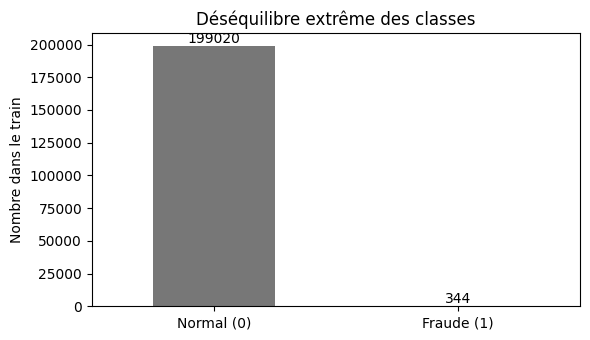

In [4]:
counts = pd.Series(y_train).value_counts().sort_index()
ax = counts.plot.bar(color=['#777777', '#111111'], figsize=(6, 3.5))
ax.set_xticklabels(['Normal (0)', 'Fraude (1)'], rotation=0)
ax.set_ylabel('Nombre dans le train')
ax.set_title('Déséquilibre extrême des classes')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout();

Le graphique explique pourquoi l'accuracy serait trompeuse : prédire toujours `normal` donnerait déjà environ 99,8 % de bonnes réponses. Nous regarderons AUC-PR, log-loss, Brier et plusieurs mesures de calibration.

## 3. Fonction commune d'évaluation

In [5]:
def evaluate(name, y_true, y_prob):
    report = discrimination_report(y_true, y_prob)
    report.update({
        'ece': expected_calibration_error(y_true, y_prob),
        'ace': adaptive_calibration_error(y_true, y_prob),
        'top_1pct_ce': top_fraction_calibration_error(
            y_true, y_prob, fraction=0.01
        ),
    })
    RESULTS[name] = report
    return pd.Series(report, name=name)

def results_table():
    return pd.DataFrame(RESULTS).T[[
        'auc_roc', 'auc_pr', 'log_loss', 'brier',
        'ece', 'ace', 'top_1pct_ce'
    ]].round(5)

## 4. Random Forest de référence

Nous commençons sans rééquilibrage. L'objectif est de mesurer séparément classement et calibration, pas de supposer à l'avance que le modèle sera mal calibré.

In [6]:
baseline = make_base_estimator(random_state=SEED)
baseline.fit(X_train, y_train)
p_baseline = baseline.predict_proba(X_test)[:, 1]
evaluate('Baseline', y_test, p_baseline)

auc_roc        0.970433
auc_pr         0.808906
log_loss       0.003334
brier          0.000506
ece            0.000295
ace            0.000254
top_1pct_ce    0.003597
Name: Baseline, dtype: float64

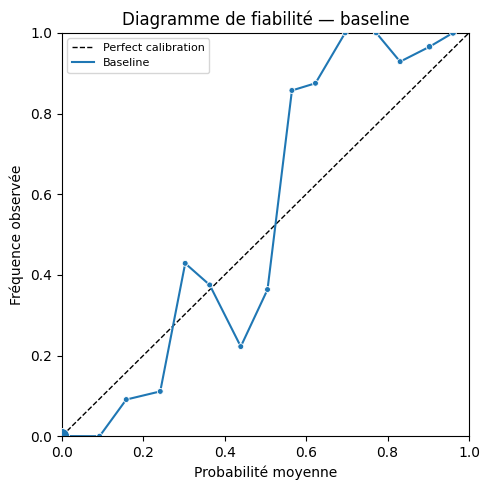

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_reliability(ax, y_test, p_baseline, label='Baseline')
ax.set_title('Diagramme de fiabilité — baseline')
plt.tight_layout();

## 5. Calibration post-hoc

Platt scaling impose une transformation sigmoïde. La régression isotone apprend une transformation monotone plus flexible. `CalibratedClassifierCV` utilise ici trois folds dans le train ; le test reste indépendant.

In [8]:
platt = platt_scaling(make_base_estimator, X_train, y_train, cv=3)
isotonic = isotonic_scaling(make_base_estimator, X_train, y_train, cv=3)

p_platt = platt.predict_proba(X_test)[:, 1]
p_isotonic = isotonic.predict_proba(X_test)[:, 1]

evaluate('Platt', y_test, p_platt)
evaluate('Isotonic', y_test, p_isotonic)
results_table()

,auc_roc,auc_pr,log_loss,brier,ece,ace,top_1pct_ce
Baseline,0.97043,0.80891,0.00333,0.00051,0.00030,0.00025,0.00360
Platt,0.97162,0.80648,0.00356,0.00053,0.00016,0.00048,0.01609
Isotonic,0.96955,0.80514,0.00321,0.00050,0.00015,0.00019,0.00411


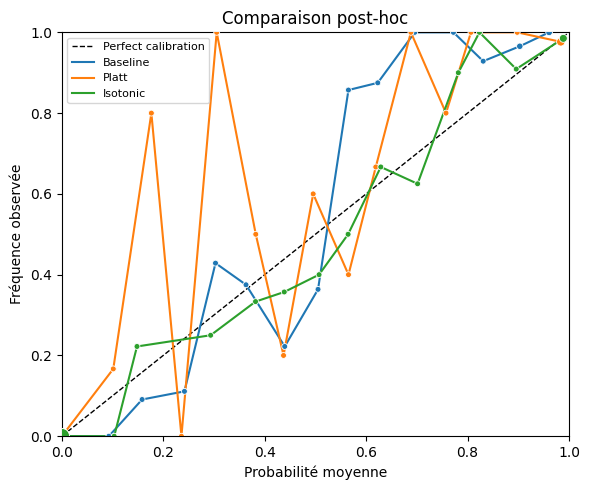

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_reliability(ax, y_test, p_baseline, label='Baseline')
plot_reliability(ax, y_test, p_platt, label='Platt')
plot_reliability(ax, y_test, p_isotonic, label='Isotonic')
ax.set_title('Comparaison post-hoc')
plt.tight_layout();

Ne concluez pas à partir de l'ECE seule. Dans la run de référence, Platt améliore l'ECE uniforme mais détériore la calibration du top 1 %, la log-loss et le Brier score.

## 6. Undersampling et correction du prior

On conserve toutes les fraudes et seulement cinq fois plus de négatifs que de positifs. `beta` mesure la fraction des négatifs d'origine conservés. Les probabilités brutes correspondent au prior artificiel du train sous-échantillonné.

In [10]:
X_us, y_us, beta = undersample(
    X_train, y_train, neg_pos_ratio=5.0, random_state=SEED
)

pd.Series({
    'prevalence_train_original': y_train.mean(),
    'prevalence_train_undersampled': y_us.mean(),
    'fraction_negatifs_conserves_beta': beta,
    'taille_train_original': len(y_train),
    'taille_train_undersampled': len(y_us),
})

prevalence_train_original                0.001725
prevalence_train_undersampled            0.166667
fraction_negatifs_conserves_beta         0.008642
taille_train_original               199364.000000
taille_train_undersampled             2064.000000
dtype: float64

In [11]:
undersampled_model = make_base_estimator(random_state=SEED)
undersampled_model.fit(X_us, y_us)
p_us_raw = undersampled_model.predict_proba(X_test)[:, 1]
p_us_corrected = correct_undersampled_probabilities(p_us_raw, beta)

evaluate('Undersampled raw', y_test, p_us_raw)
evaluate('Undersampled corrected', y_test, p_us_corrected)
results_table()

,auc_roc,auc_pr,log_loss,brier,ece,ace,top_1pct_ce
Baseline,0.97043,0.80891,0.00333,0.00051,0.00030,0.00025,0.00360
Platt,0.97162,0.80648,0.00356,0.00053,0.00016,0.00048,0.01609
Isotonic,0.96955,0.80514,0.00321,0.00050,0.00015,0.00019,0.00411
Undersampled raw,0.97012,0.64246,0.03898,0.00461,0.03050,0.03050,0.38708
Undersampled corrected,0.97012,0.64246,0.00780,0.00095,0.00075,0.00050,0.04041


In [12]:
example = pd.DataFrame({'p_sampled': [0.05, 0.20, 0.50, 0.80]})
example['p_population'] = correct_undersampled_probabilities(
    example['p_sampled'].to_numpy(), beta
)
example

,p_sampled,p_population
0,0.05,0.000455
1,0.20,0.002156
2,0.50,0.008568
3,0.80,0.033414


La correction réduit les probabilités mais conserve leur ordre. L'AUC reste donc identique avant/après, tandis que la calibration change fortement.

## 7. Expérience soft-ECE

Deux MLP identiques sont entraînés sur le même train sous-échantillonné. Le premier utilise seulement la BCE ; le second ajoute la loss soft-ECE. On applique ensuite la même correction de prior aux deux sorties pour isoler autant que possible l'effet de la loss.

In [13]:
X_us_nn, y_us_nn, beta_nn = undersample(
    X_train, y_train, neg_pos_ratio=10.0, random_state=1
)
scaler = StandardScaler().fit(X_us_nn)
X_us_nn_scaled = scaler.transform(X_us_nn)
X_test_scaled = scaler.transform(X_test)

_, p_plain_sampled = train_mlp(
    X_us_nn_scaled, y_us_nn, X_test_scaled,
    calibration_weight=0.0, n_epochs=25, seed=SEED
)
_, p_soft_sampled = train_mlp(
    X_us_nn_scaled, y_us_nn, X_test_scaled,
    calibration_weight=0.5, n_epochs=25, seed=SEED
)

p_plain = correct_undersampled_probabilities(p_plain_sampled, beta_nn)
p_soft = correct_undersampled_probabilities(p_soft_sampled, beta_nn)

evaluate('MLP BCE', y_test, p_plain)
evaluate('MLP BCE + soft-ECE', y_test, p_soft)
results_table()

,auc_roc,auc_pr,log_loss,brier,ece,ace,top_1pct_ce
Baseline,0.97043,0.80891,0.00333,0.00051,0.00030,0.00025,0.00360
Platt,0.97162,0.80648,0.00356,0.00053,0.00016,0.00048,0.01609
Isotonic,0.96955,0.80514,0.00321,0.00050,0.00015,0.00019,0.00411
Undersampled raw,0.97012,0.64246,0.03898,0.00461,0.03050,0.03050,0.38708
Undersampled corrected,0.97012,0.64246,0.00780,0.00095,0.00075,0.00050,0.04041
MLP BCE,0.97050,0.68665,0.00486,0.00070,0.00043,0.00010,0.00520
MLP BCE + soft-ECE,0.96885,0.69009,0.00485,0.00069,0.00050,0.00015,0.00139


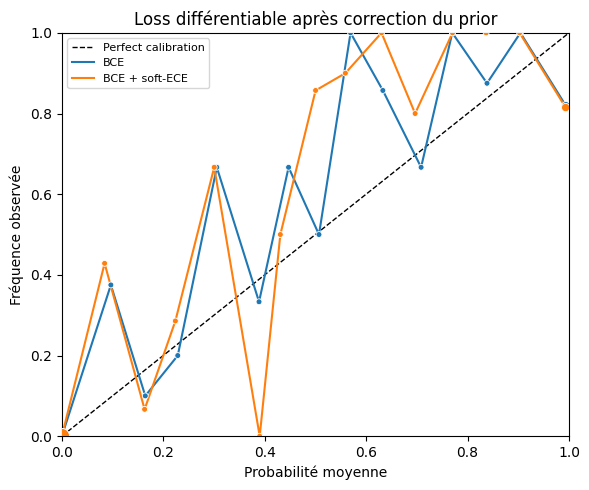

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_reliability(ax, y_test, p_plain, label='BCE')
plot_reliability(ax, y_test, p_soft, label='BCE + soft-ECE')
ax.set_title('Loss différentiable après correction du prior')
plt.tight_layout();

## 8. Conclusion

Dans la run de référence, la soft-ECE améliore nettement le gap du top 1 % et très légèrement log-loss/Brier, mais détériore un peu ECE/ACE et AUC-ROC. La conclusion n'est donc pas que cette loss résout la calibration : elle déplace le compromis entre calibration locale, calibration globale et discrimination.

Limites : une seule seed, poids soft-ECE exploratoire, expérience binaire, absence d'intervalles d'incertitude.

## 9. Export optionnel du tableau

Cette cellule écrit uniquement un CSV léger ; les données bancaires brutes restent exclues par `.gitignore`.

In [15]:
output_path = Path('results/notebook_metrics.csv')
results_table().to_csv(output_path)
print(f'Résultats écrits dans {output_path}')

Résultats écrits dans results\notebook_metrics.csv
